# Prediccion de Enjambrazon con datos a 15 minutos (+ features nocturnas 22h-7h)

**Objetivo:** predecir enjambrazones usando la resolucion completa de 15 minutos de los sensores,
explotando la ventana de actividad matutina (10-14h) y senales nocturnas (22h-7h) donde se producen
la mayoria de los enjambres.

**Diferencia clave respecto a `02_swarm_morning_window.ipynb`:** anade 13 features nocturnas
(frecuencia, peso y volumen entre las 22h y las 7h) calculadas directamente de los datos raw sin
forward-fill, para evitar contaminacion de la senal.

**Features clave:** incluye `weight_std_roll14` (validada con ablation study, +0.013 AUC sobre
XGBoost en este notebook). El modelo final usa LSTM unidireccional, que es el mejor de los 8 modelos
probados en los notebooks 02 y 03 (Secciones 7 y 7.2).

**Pipeline:**
1. Datos raw a 15-min -> resample + forward-fill (max. 2h de gap)
2. Features diarias + ventana 10-14h + features nocturnas 22h-7h + `weight_std_roll14`
3. **Modelo A** — XGBoost 3 dias (baseline sin signal + con `weight_std_roll14`)
4. **Modelo A-LSTM** — LSTM Uni y Bi sobre las mismas features (mejor resultado: LSTM Uni)
5. **Modelo B** — Deteccion de anomalia el mismo dia (z-score + XGBoost)
6. Validacion walk-forward y analisis a nivel de evento (enjambres detectados / falsas alarmas)

**Colmenas:** Box1-Box5, Box8, Box13, Box14 (con enjambrazones registradas)
**Cobertura temporal:** febrero-junio (temporada de enjambrazon)

**Mejor resultado:** LSTM Uni — AUC=0.887, 13/14 eventos de test detectados, 218 falsas alarmas
(el mejor modelo de toda la comparativa).

## 1. Imports y constantes

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              classification_report, confusion_matrix,
                              precision_recall_curve, roc_curve)
from xgboost import XGBClassifier

RAW_CSV        = '../../data/12062026all_boxes.csv'
SWARM_BOXES    = [1, 2, 3, 4, 5, 8, 13, 14]   # hives with recorded swarms
SWARM_HOUR_S   = 10                             # swarm window start (inclusive)
SWARM_HOUR_E   = 14                             # swarm window end   (inclusive)
SPLIT_DATE     = '2026-01-01'                   # train < SPLIT_DATE ; test >= SPLIT_DATE
SEED           = 42

# colour palette (one per hive)
BOX_COLORS = {1:'#e41a1c',2:'#377eb8',3:'#4daf4a',4:'#984ea3',
               5:'#ff7f00',8:'#a65628',13:'#f781bf',14:'#999999'}
print('Imports OK')

Imports OK


## 2. Carga del CSV raw

Se carga el archivo de sensores completo (toda la resolucion de 15 min) y se renombran las columnas
a nombres estandar para unificar con el resto de notebooks.


In [2]:
raw = pd.read_csv(RAW_CSV)
raw = raw.rename(columns={
    'Hive name'        : 'box_id',
    'Temperature heart': 'Temp_heart',
    'Humidity heart'   : 'Hum_heart',
    'Temperature scale': 'Temp_scale',
    'Humidity scale'   : 'Hum_scale',
})
raw['Time'] = pd.to_datetime(raw['Time'], format='mixed', dayfirst=False)

print('Raw shape:', raw.shape)
print('Columns:', list(raw.columns))
print('box_ids:', sorted(raw['box_id'].dropna().unique()))
print('Date range:', raw['Time'].min().date(), '->', raw['Time'].max().date())
print('NaN% each column:')
print((raw.isnull().mean()*100).round(1))

Raw shape: (4536715, 9)
Columns: ['box_id', 'Time', 'Temp_heart', 'Hum_heart', 'Frequency', 'Volume', 'Temp_scale', 'Hum_scale', 'Weight']
box_ids: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
Date range: 2023-01-01 -> 2026-06-12
NaN% each column:
box_id         0.0
Time           0.0
Temp_heart    59.6
Hum_heart     59.6
Frequency     59.6
Volume        59.6
Temp_scale    44.3
Hum_scale     44.3
Weight        44.3
dtype: float64


## 3. Filtro estacional y resample a 15 minutos

Se filtra a los meses de febrero-junio (temporada de enjambrazon) y se remuestrea a intervalos regulares de 15 min.
Los gaps de hasta 2 horas se rellenan con el ultimo valor conocido (`ffill(limit=8)`);
los gaps mas largos se dejan como NaN para no inventar datos.


In [3]:
# Filter to swarm hives + Feb-Jun only
df_raw = raw[
    raw['box_id'].isin(SWARM_BOXES) &
    raw['Time'].dt.month.between(2, 6)
].copy()

# Clip weight to biological range — sensor overflows at ±327.68 kg
df_raw['Weight'] = df_raw['Weight'].where(df_raw['Weight'].between(3, 120), np.nan)

print('After filter:', df_raw.shape)

# Resample each hive to 15-min grid (mean).  Alternating sensors → each window
# receives ~2 readings per sensor type → mean fills both naturally.
frames = []
for box in SWARM_BOXES:
    sub = (df_raw[df_raw['box_id']==box]
           .set_index('Time')
           [['Weight','Frequency','Volume','Temp_scale','Hum_scale',
             'Temp_heart','Hum_heart']]
           .resample('15min').mean())
    # Forward-fill gaps ≤ 2 hours (8 periods × 15 min)
    sub = sub.ffill(limit=8)
    sub['box_id'] = box
    sub = sub.reset_index().rename(columns={'index':'Time'})
    frames.append(sub)

df15 = pd.concat(frames, ignore_index=True)
df15 = df15.sort_values(['box_id','Time']).reset_index(drop=True)

# Remove manual-inspection spikes: |ΔWeight| > 5 kg in one 15-min step
def _remove_spikes(s, thr=5.0):
    spike = s.diff().abs() > thr  # NaN diff (first row) -> False -> not removed
    return s.where(~spike)
df15['Weight'] = df15.groupby('box_id')['Weight'].transform(_remove_spikes)

print('15-min resampled shape:', df15.shape)
print('NaN% after resample+ffill:')
cols_sensor = ['Weight','Frequency','Volume','Temp_scale','Temp_heart']
print((df15[cols_sensor].isnull().mean()*100).round(1))
print('\nSample:')
df15.head(3)

After filter: (1198189, 9)


15-min resampled shape: (866356, 9)
NaN% after resample+ffill:
Weight        55.6
Frequency     62.4
Volume        62.4
Temp_scale    53.4
Temp_heart    62.4
dtype: float64

Sample:


,Time,Weight,Frequency,Volume,Temp_scale,Hum_scale,Temp_heart,Hum_heart,box_id
0,2023-02-01 00:00:00,10.70,67.35,0.10,1.5,62.7,5.65,65.1,1
1,2023-02-01 00:15:00,10.72,80.30,0.00,1.3,63.1,5.40,65.1,1
2,2023-02-01 00:30:00,10.74,74.30,0.05,1.3,63.5,5.20,64.9,1


## 4. Eventos de enjambrazon (etiquetas)

Los 23 eventos de enjambre se definen manualmente a partir del registro de Gerardo.
Son los mismos eventos que en `enjambrazon.ipynb` para garantizar coherencia entre notebooks.

Se genera un set `SWARM_SET = {(box_id, date)}` para la etiquetacion eficiente.


In [4]:
# 23 known events: (box_id, date)
SWARM_EVENTS = [
    (2,  '2024-05-24'),
    (13, '2025-04-04'), (13, '2025-04-07'), (13, '2025-04-08'), (13, '2025-04-16'),
    (3,  '2025-04-17'), (14, '2025-04-18'), (3,  '2025-04-23'), (4,  '2025-04-23'),
    (1,  '2026-04-07'), (1,  '2026-04-23'),
    (4,  '2026-04-23'), (4,  '2026-04-24'),
    (5,  '2026-04-25'), (8,  '2026-04-29'),
    (5,  '2026-05-01'), (8,  '2026-05-05'),
    (3,  '2026-05-10'), (4,  '2026-05-10'), (8,  '2026-05-11'),
    (3,  '2026-05-14'), (3,  '2026-05-17'),
    (14, '2026-06-01'),
]

df_events = pd.DataFrame(SWARM_EVENTS, columns=['box_id','date'])
df_events['date'] = pd.to_datetime(df_events['date'])

# Add a 'date' column to 15-min df for joins
df15['date'] = df15['Time'].dt.normalize()

# Mark swarm-day rows
swarm_set = set(zip(df_events['box_id'], df_events['date']))
df15['swarm_today'] = [
    1 if (b, d) in swarm_set else 0
    for b, d in zip(df15['box_id'], df15['date'])
]

print('Total 15-min rows:', len(df15))
print('Swarm-day rows:', df15['swarm_today'].sum(),
      '  (%.2f%%)' % (df15['swarm_today'].mean()*100))
print('Events per box:'); print(df_events['box_id'].value_counts().sort_index())

Total 15-min rows: 866356
Swarm-day rows: 2208   (0.25%)
Events per box:
box_id
1     2
2     1
3     5
4     4
5     2
8     3
13    4
14    2
Name: count, dtype: int64


## 5. Ingenieria de features

Para cada colmena y cada dia se calculan dos bloques de features:

**Features diarias (agregado de todo el dia):**
- Estadisticos del peso: media, min, max, std
- Estadisticos de frecuencia acustica: media, max, std
- Estadisticos de volumen de sonido: media, max
- Medias moviles y diferencias de peso (7 y 14 dias)
- Media movil de frecuencia (7 dias) y correlacion peso-temperatura (14 dias)
- Dias desde el ultimo enjambre de esa colmena

**Features de la ventana matutina (10-14h):**
- `win_Weight_drop`: caida de peso durante la manana (senal de salida del enjambre)
- `win_Freq_max`: frecuencia maxima durante la manana (senal de actividad de vuelo)
- `freq_spike_ratio`: ratio entre `win_Freq_max` del dia y la mediana de los ultimos 7 dias
  (detecta spikes anomalos de frecuencia independientemente del nivel base de cada colmena)
- `win_Weight_range`: rango de peso durante la manana


In [5]:
# We build TWO feature tables:
#   (A) daily_feat  → one row per (box, day)  for the 3-day prediction model
#   (B) window_feat → one row per (box, day)  with 10-14h window stats only
#                     for the same-day anomaly model

daily = (
    df15.groupby(['box_id','date'])
    .agg(
        Weight_mean   = ('Weight',    'mean'),
        Weight_min    = ('Weight',    'min'),
        Weight_max    = ('Weight',    'max'),
        Weight_std    = ('Weight',    'std'),
        Freq_mean     = ('Frequency', 'mean'),
        Freq_max      = ('Frequency', 'max'),
        Freq_std      = ('Frequency', 'std'),
        Vol_mean      = ('Volume',    'mean'),
        Vol_max       = ('Volume',    'max'),
        Temp_mean     = ('Temp_scale','mean'),
        Temp_max      = ('Temp_scale','max'),
    )
    .reset_index()
)

morning = df15[
    df15['Time'].dt.hour.between(SWARM_HOUR_S, SWARM_HOUR_E - 1)  # 10,11,12,13
].copy()

win = (
    morning.groupby(['box_id','date'])
    .agg(
        win_Weight_first = ('Weight',    'first'),
        win_Weight_last  = ('Weight',    'last'),
        win_Weight_min   = ('Weight',    'min'),
        win_Weight_max   = ('Weight',    'max'),
        win_Weight_std   = ('Weight',    'std'),
        win_Freq_mean    = ('Frequency', 'mean'),
        win_Freq_max     = ('Frequency', 'max'),
        win_Freq_std     = ('Frequency', 'std'),
        win_Vol_mean     = ('Volume',    'mean'),
        win_Vol_max      = ('Volume',    'max'),
    )
    .reset_index()
)
# Window derived features
win['win_Weight_drop']  = win['win_Weight_first'] - win['win_Weight_last']   # + = loss
win['win_Weight_range'] = win['win_Weight_max']   - win['win_Weight_min']
# Frequency anomaly: how many times above hive's own rolling median

# Merge daily + window
feat_day = daily.merge(win, on=['box_id','date'], how='left')

feat_day = feat_day.sort_values(['box_id','date']).reset_index(drop=True)
# ── Nighttime features (22h-8h) — pre-swarm nocturnal signals ─────────────────
# Use df_raw (original readings, no ffill) to get true night sensor values.
# Coverage: sensors record at night ~29-49% of the time per box (uniform across hours).
# Readings 22h-23h of day D → re-assigned to day D+1 (pre-dawn context for D+1)
_night_raw = df_raw.copy()
_night_raw['Weight'] = _night_raw['Weight'].where(_night_raw['Weight'].between(3, 120), np.nan)
_night_raw['_date'] = _night_raw['Time'].dt.normalize()
_late = _night_raw['Time'].dt.hour >= 22
_night_raw['_night_date'] = _night_raw['_date'].copy()
_night_raw.loc[_late, '_night_date'] = _night_raw.loc[_late, '_date'] + pd.Timedelta(days=1)
_night_raw = _night_raw[
    (_night_raw['Time'].dt.hour >= 22) | (_night_raw['Time'].dt.hour <= 7)
].copy()

night_agg = (
    _night_raw.groupby(['box_id', '_night_date'])
    .agg(
        night_Freq_mean  = ('Frequency', 'mean'),
        night_Freq_max   = ('Frequency', 'max'),
        night_Freq_std   = ('Frequency', 'std'),
        night_Weight_mean= ('Weight',    'mean'),
        night_Vol_mean   = ('Volume',    'mean'),
        night_Vol_max    = ('Volume',    'max'),
    )
    .reset_index()
    .rename(columns={'_night_date': 'date'})
)

# Overnight weight delta: early morning (6-9h) minus previous evening (18-21h)
# Using raw data for both (no ffill contamination)
_raw_dated = df_raw.copy()
_raw_dated['Weight'] = _raw_dated['Weight'].where(_raw_dated['Weight'].between(3, 120), np.nan)
_raw_dated['_date'] = _raw_dated['Time'].dt.normalize()

_prev_eve = (
    _raw_dated[_raw_dated['Time'].dt.hour.between(18, 21)]
    .assign(date=lambda d: d['_date'] + pd.Timedelta(days=1))
    .groupby(['box_id', 'date'])['Weight'].mean()
    .reset_index().rename(columns={'Weight': '_eve_w'})
)
_early_morn = (
    _raw_dated[_raw_dated['Time'].dt.hour.between(6, 9)]
    .assign(date=lambda d: d['_date'])
    .groupby(['box_id', 'date'])['Weight'].mean()
    .reset_index().rename(columns={'Weight': '_morn_w'})
)
_wdelta = _prev_eve.merge(_early_morn, on=['box_id', 'date'], how='inner')
_wdelta['night_weight_delta'] = _wdelta['_morn_w'] - _wdelta['_eve_w']
_wdelta = _wdelta[['box_id', 'date', 'night_weight_delta']]

feat_day = feat_day.merge(night_agg, on=['box_id', 'date'], how='left')
feat_day = feat_day.merge(_wdelta,   on=['box_id', 'date'], how='left')


def add_rolling(df):
    rows = []
    for box, grp in df.groupby('box_id', sort=False):
        grp = grp.sort_values('date').copy()
        W = grp['Weight_mean']
        F = grp['Freq_mean']
        T = grp['Temp_mean']
        # weight trends
        grp['w_ma7']   = W.rolling(7,  min_periods=3).mean()
        grp['w_ma14']  = W.rolling(14, min_periods=5).mean()
        grp['w_diff7'] = W - W.shift(7)
        grp['w_diff14']= W - W.shift(14)
        # 14-day rolling std of daily mean weight — variability/instability signal
        grp['weight_std_roll14'] = W.rolling(14, min_periods=7).std()
        # freq trends
        grp['f_ma7']   = F.rolling(7,  min_periods=3).mean()
        grp['f_diff7'] = F - F.shift(7)
        # corr weight vs temp (14-day rolling)
        grp['corr_w_temp'] = W.rolling(14, min_periods=7).corr(T)
        # freq spike ratio vs 7d rolling median  (today's max / rolling median)
        freq_med7 = grp['Freq_max'].rolling(7, min_periods=3).median().shift(1)
        grp['freq_spike_ratio'] = grp['win_Freq_max'] / freq_med7.where(freq_med7 >= 10)
        # Night frequency rolling trends
        NF    = grp['night_Freq_mean']
        NFmax = grp['night_Freq_max']
        grp['night_f_ma3']    = NF.rolling(3, min_periods=2).mean()
        grp['night_f_ma7']    = NF.rolling(7, min_periods=3).mean()
        grp['night_fmax_ma3'] = NFmax.rolling(3, min_periods=2).mean()
        grp['night_fmax_ma7'] = NFmax.rolling(7, min_periods=3).mean()
        # Night spike: tonight vs 7d rolling median of night freq
        _nmed7 = NFmax.rolling(7, min_periods=3).median().shift(1)
        grp['night_freq_spike_ratio'] = NFmax / _nmed7.where(_nmed7 >= 10)
        # Night-to-morning ratio: how much morning exceeds previous night
        grp['night_to_morning_freq']  = grp['win_Freq_max'] / NFmax.where(NFmax >= 10)
        # Overnight weight delta rolling
        NWD = grp['night_weight_delta']
        grp['night_wdelta_ma3'] = NWD.rolling(3, min_periods=2).mean()
        # days since last swarm
        grp['days_since_swarm'] = np.nan
        last = pd.NaT
        for i, row in grp.iterrows():
            if last is not pd.NaT:
                grp.loc[i,'days_since_swarm'] = (row['date'] - last).days
            if (box, row['date']) in swarm_set:
                last = row['date']
        grp['has_prior_swarm'] = (~grp['days_since_swarm'].isna()).astype(int)
        grp['days_since_swarm']  = grp['days_since_swarm'].fillna(999)
        grp['day_of_year']       = grp['date'].dt.dayofyear
        rows.append(grp)
    return pd.concat(rows, ignore_index=True)

feat_day = add_rolling(feat_day)
# Remove off-season rows created by resample time-span (Jul-Jan gaps are all-NaN)
feat_day = feat_day[feat_day['date'].dt.month.between(2, 6)].reset_index(drop=True)
# Replace inf (corr_w_temp can produce inf when weight variance ≈ 0)
feat_day = feat_day.replace([np.inf, -np.inf], np.nan)

# Attach swarm label
feat_day['swarm_today'] = [
    1 if (b,d) in swarm_set else 0
    for b,d in zip(feat_day['box_id'], feat_day['date'])
]

print('feat_day shape:', feat_day.shape)
print('Positive rate:', feat_day['swarm_today'].mean().round(4))
feat_day.head(2)

feat_day shape: (4298, 52)
Positive rate: 0.0054


,box_id,date,Weight_mean,Weight_min,Weight_max,Weight_std,Freq_mean,Freq_max,Freq_std,Vol_mean,...,night_f_ma7,night_fmax_ma3,night_fmax_ma7,night_freq_spike_ratio,night_to_morning_freq,night_wdelta_ma3,days_since_swarm,has_prior_swarm,day_of_year,swarm_today
0,1,2023-02-01,10.794531,10.530,11.11,0.163219,79.655208,98.05,9.848004,0.203646,...,NaN,NaN,NaN,NaN,0.955193,NaN,999.0,0,32,0
1,1,2023-02-02,10.718854,10.365,11.11,0.237514,80.274479,96.45,9.943903,0.250521,...,NaN,99.45,NaN,NaN,0.947368,NaN,999.0,0,33,0


## 6. Analisis exploratorio (EDA)

### 6.1 Ventana matutina en dias de enjambre

Para cada evento de enjambre registrado se visualiza el perfil de peso y frecuencia en la ventana 10-14h.
Esto permite validar visualmente si las features de la ventana capturan el comportamiento esperado.


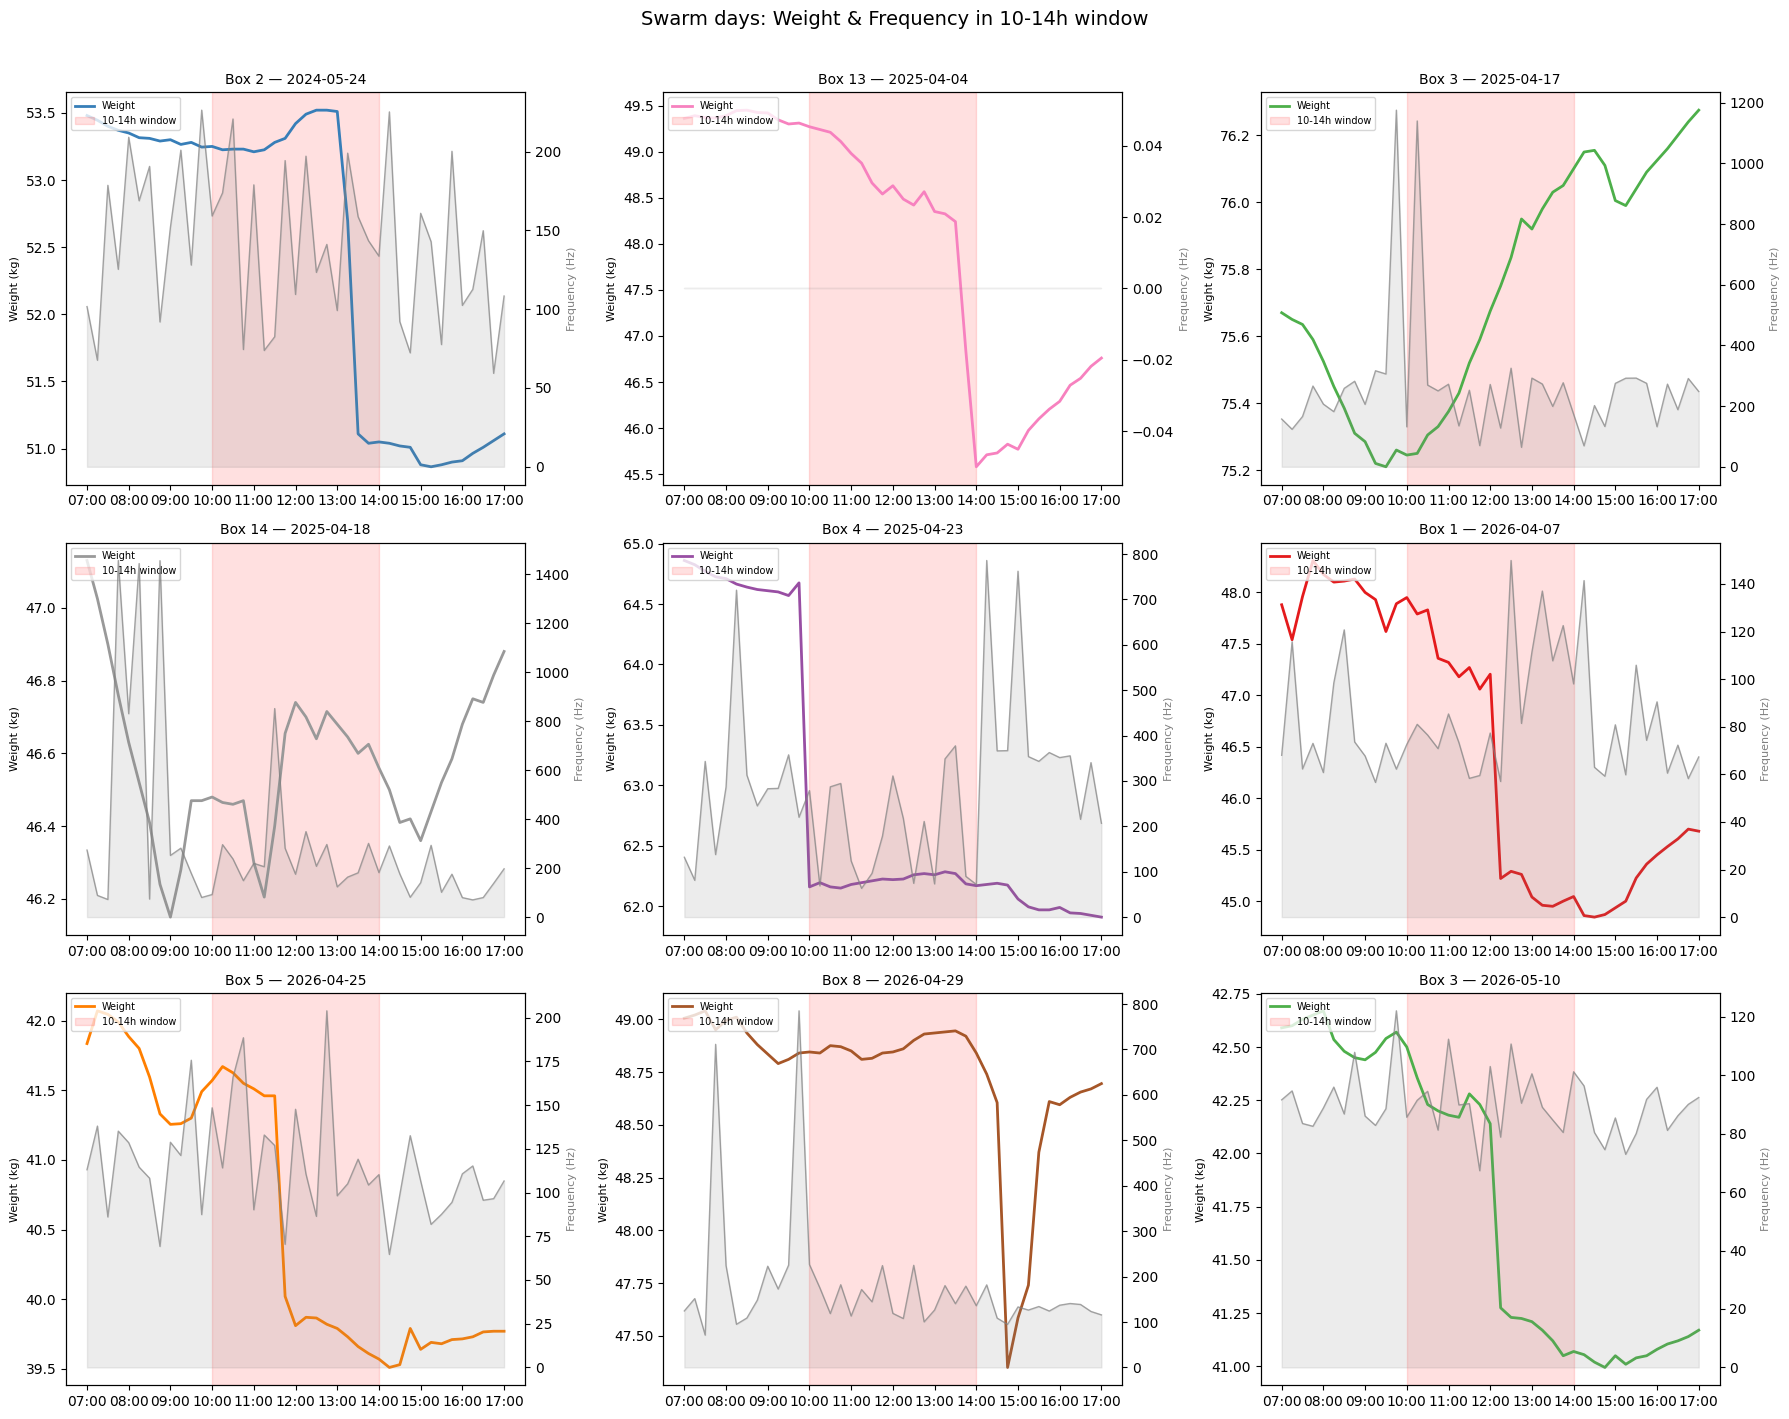

Plot saved.


In [6]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()
ax_idx = 0

# Show weight + frequency for the 10-14h window ± 2h around each swarm event
sample_events = [(2,'2024-05-24'),  (13,'2025-04-04'), (3,'2025-04-17'),
                 (14,'2025-04-18'), (4,'2025-04-23'),  (1,'2026-04-07'),
                 (5,'2026-04-25'),  (8,'2026-04-29'),  (3,'2026-05-10')]

for box, date_str in sample_events:
    ax = axes[ax_idx]; ax_idx += 1
    d = pd.Timestamp(date_str)
    sub = df15[
        (df15['box_id']==box) &
        (df15['Time'] >= d + pd.Timedelta(hours=7)) &
        (df15['Time'] <= d + pd.Timedelta(hours=17))
    ].copy()
    color = BOX_COLORS.get(box,'k')
    ax2 = ax.twinx()
    ax.plot(sub['Time'], sub['Weight'],    color=color,  lw=2, label='Weight')
    ax2.plot(sub['Time'], sub['Frequency'], color='gray', lw=1, alpha=0.7, label='Freq')
    ax2.fill_between(sub['Time'], 0, sub['Frequency'].fillna(0),
                     alpha=0.15, color='gray')
    # Shade swarm window
    ax.axvspan(d+pd.Timedelta(hours=SWARM_HOUR_S),
               d+pd.Timedelta(hours=SWARM_HOUR_E),
               alpha=0.12, color='red', label='10-14h window')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.set_title(f'Box {box} — {date_str}', fontsize=10)
    ax.set_ylabel('Weight (kg)', fontsize=8)
    ax2.set_ylabel('Frequency (Hz)', fontsize=8, color='gray')
    ax.legend(fontsize=7, loc='upper left')

plt.suptitle('Swarm days: Weight & Frequency in 10-14h window', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('enjambrazon2_swarm_days_eda.png', dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved.')

### 6.2 Distribucion de features: dias de enjambre vs. dias normales

Comparativa de las distribuciones de `win_Freq_max`, `win_Weight_drop` y `freq_spike_ratio`
en dias con y sin enjambre. Permite identificar que features discriminan mejor.


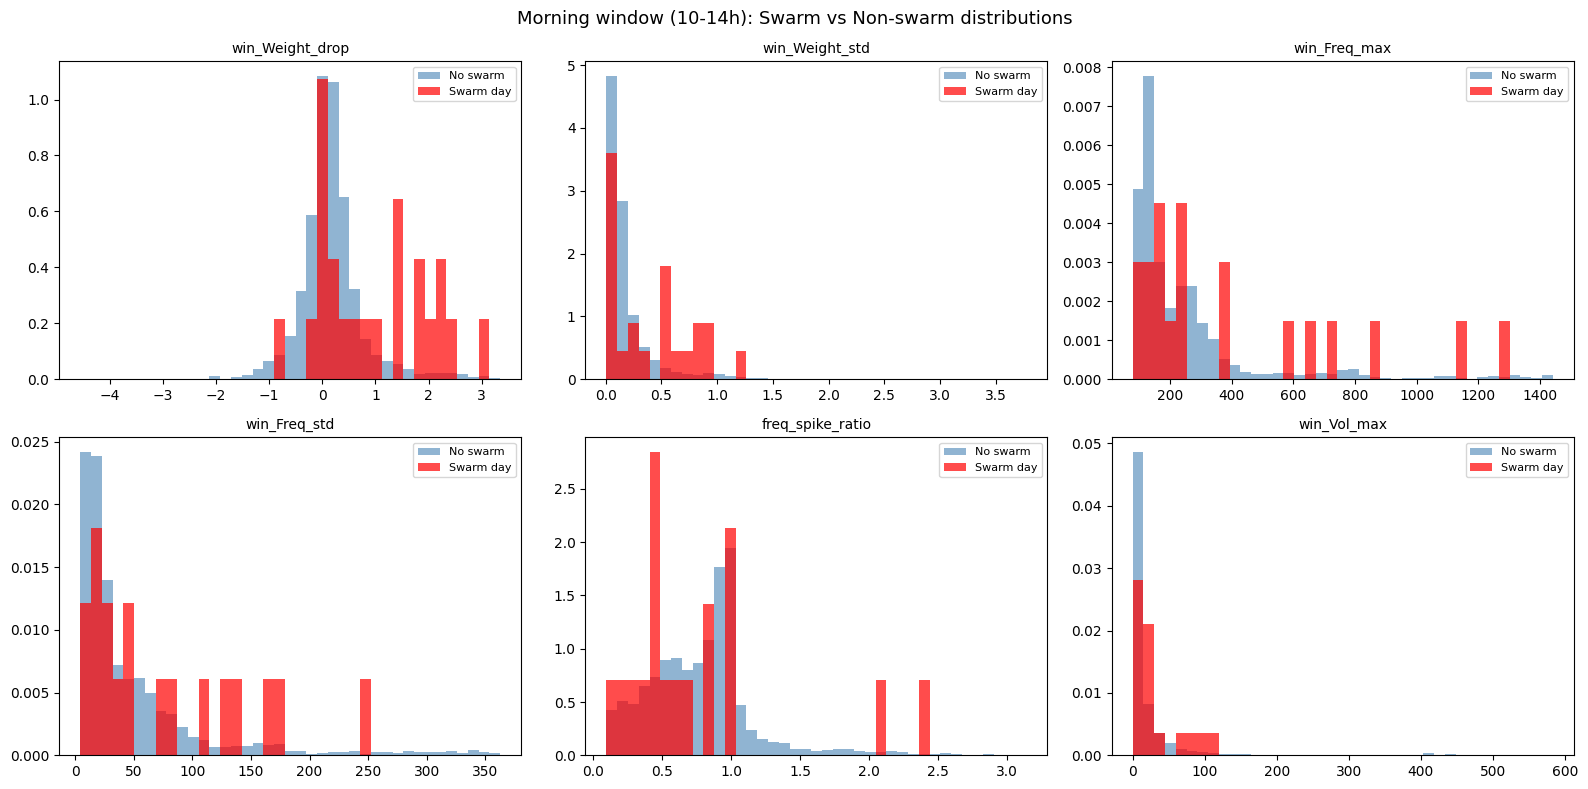

In [7]:
swarm_mask = feat_day['swarm_today'] == 1
win_features = ['win_Weight_drop','win_Weight_std','win_Freq_max',
                'win_Freq_std','freq_spike_ratio','win_Vol_max']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, win_features):
    data_pos = feat_day.loc[swarm_mask,   col].dropna()
    data_neg = feat_day.loc[~swarm_mask,  col].dropna()
    # clip for readability
    lo, hi = np.percentile(pd.concat([data_pos,data_neg]), [1,99])
    bins = np.linspace(lo, hi, 40)
    ax.hist(data_neg, bins=bins, alpha=0.6, color='steelblue', label='No swarm', density=True)
    ax.hist(data_pos, bins=bins, alpha=0.7, color='red',       label='Swarm day', density=True)
    ax.set_title(col, fontsize=10)
    ax.legend(fontsize=8)

plt.suptitle('Morning window (10-14h): Swarm vs Non-swarm distributions', fontsize=13)
plt.tight_layout()
plt.savefig('enjambrazon2_window_dists.png', dpi=120, bbox_inches='tight')
plt.show()

## 7. Modelo A — XGBoost, prediccion 3 dias antes

XGBoost entrenado con todas las features (diarias + ventana matutina) para predecir si habra
un enjambre en los proximos 3 dias.

- **Split:** train = hasta 31/12/2025, test = 2026 (estricto, sin data leakage)
- **`scale_pos_weight`** calculado sobre el set de entrenamiento para compensar el desequilibrio
- **Umbral optimo** seleccionado por G-Mean sobre la curva ROC del test
- **Early stopping** desactivado (sin leakage del test en el numero de arboles)


In [8]:
# Label: will there be a swarm in the next 3 days (exclusive of today)?

HORIZON = 3   # days ahead

def make_horizon_labels(feat, df_ev, horizon):
    """For each (box, date) row, target=1 if any swarm event in [date+1, date+horizon]."""
    ev_set = set(zip(df_ev['box_id'], df_ev['date']))
    labels = []
    for _, row in feat.iterrows():
        hit = 0
        for delta in range(1, horizon + 1):
            if (row['box_id'], row['date'] + pd.Timedelta(days=delta)) in ev_set:
                hit = 1; break
        labels.append(hit)
    return np.array(labels)

feat_day['target_3d'] = make_horizon_labels(feat_day, df_events, HORIZON)
print('Target_3d positive rate:', feat_day['target_3d'].mean().round(4))

FEAT_A = [
    # Daily weight signals
    'Weight_mean','Weight_std','Weight_min','Weight_max',
    'w_ma7','w_ma14','w_diff7','w_diff14','weight_std_roll14',
    # Daily freq / vol signals
    'Freq_mean','Freq_max','Freq_std','f_ma7','f_diff7',
    'Vol_mean','Vol_max',
    'Temp_mean','Temp_max',
    'corr_w_temp',
    'days_since_swarm','has_prior_swarm','day_of_year',
    # Morning window features (10-14h)
    'win_Weight_drop','win_Weight_std','win_Weight_range',
    'win_Freq_max','win_Freq_std','win_Freq_mean',
    'win_Vol_max','win_Vol_mean',
    'freq_spike_ratio',
    # Nighttime features (22h-8h, assigned to morning date D)
    'night_Freq_mean','night_Freq_max','night_Freq_std',
    'night_Vol_mean','night_Vol_max','night_Weight_mean',
    'night_weight_delta',
    'night_f_ma7','night_fmax_ma7','night_fmax_ma3',
    'night_freq_spike_ratio','night_to_morning_freq','night_wdelta_ma3',
]

# Remove cols with too many NaNs
nan_frac = feat_day[FEAT_A].isnull().mean()
FEAT_A = [c for c in FEAT_A if nan_frac[c] < 0.5]
print('Features used:', len(FEAT_A))

split = pd.Timestamp(SPLIT_DATE)
tr = feat_day[feat_day['date'] <  split].copy()
te = feat_day[feat_day['date'] >= split].copy()

# Replace inf before fillna (freq_spike_ratio can produce inf with extreme values)
_med = tr[FEAT_A].replace([np.inf, -np.inf], np.nan).median()
X_tr = tr[FEAT_A].replace([np.inf, -np.inf], np.nan).fillna(_med)
y_tr = tr['target_3d'].values
X_te = te[FEAT_A].replace([np.inf, -np.inf], np.nan).fillna(_med)
y_te = te['target_3d'].values

print(f'Train: {len(tr)} rows, {y_tr.mean():.3f} pos rate')
print(f'Test:  {len(te)} rows, {y_te.mean():.3f} pos rate')

spw = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
print(f'scale_pos_weight: {spw:.1f}')

xgb_a = XGBClassifier(
    n_estimators       = 400,
    max_depth          = 4,
    learning_rate      = 0.05,
    subsample          = 0.8,
    colsample_bytree   = 0.8,
    scale_pos_weight   = spw,
    eval_metric        = 'aucpr',
    random_state       = SEED,
    verbosity          = 0,
)
xgb_a.fit(X_tr, y_tr)

prob_a = xgb_a.predict_proba(X_te)[:,1]
auc_a  = roc_auc_score(y_te, prob_a)
ap_a   = average_precision_score(y_te, prob_a)

# Optimal threshold by max G-Mean on ROC curve
fpr_a, tpr_a, thr_roc_a = roc_curve(y_te, prob_a)
gmean_roc_a = np.sqrt(tpr_a * (1 - fpr_a))
best_idx_a  = np.argmax(gmean_roc_a)
best_thr_a  = float(thr_roc_a[best_idx_a])
sensitivity_a = float(tpr_a[best_idx_a])
specificity_a = float(1 - fpr_a[best_idx_a])
gmean_a       = float(gmean_roc_a[best_idx_a])
pred_a = (prob_a >= best_thr_a).astype(int)

print(f'\n── Model A (3-day XGBoost) ──')
print(f'AUC-ROC : {auc_a:.3f}')
print(f'Avg Prec: {ap_a:.3f}')
print(f'G-Mean  : {gmean_a:.3f}  (thr={best_thr_a:.4f})')
print(f'Sensitivity: {sensitivity_a:.3f}   Specificity: {specificity_a:.3f}')
print(classification_report(y_te, pred_a, target_names=['No swarm','Swarm in 3d']))

Target_3d positive rate: 0.0151
Features used: 44
Train: 3308 rows, 0.008 pos rate
Test:  990 rows, 0.040 pos rate
scale_pos_weight: 131.3



── Model A (3-day XGBoost) ──
AUC-ROC : 0.717
Avg Prec: 0.141
G-Mean  : 0.715  (thr=0.0002)
Sensitivity: 0.650   Specificity: 0.787
              precision    recall  f1-score   support

    No swarm       0.98      0.79      0.87       950
 Swarm in 3d       0.11      0.65      0.19        40

    accuracy                           0.78       990
   macro avg       0.55      0.72      0.53       990
weighted avg       0.95      0.78      0.85       990



### 7.1 Importancia de features y curva Precision-Recall

Las 15 features mas importantes para el Modelo A y la curva Precision-Recall en test.
El AP bajo refleja la dificultad del problema: hay muy pocos dias de enjambre en el anno.
Se incluye tambien la validacion walk-forward (train<2025->test2025 y train<2026->test2026).


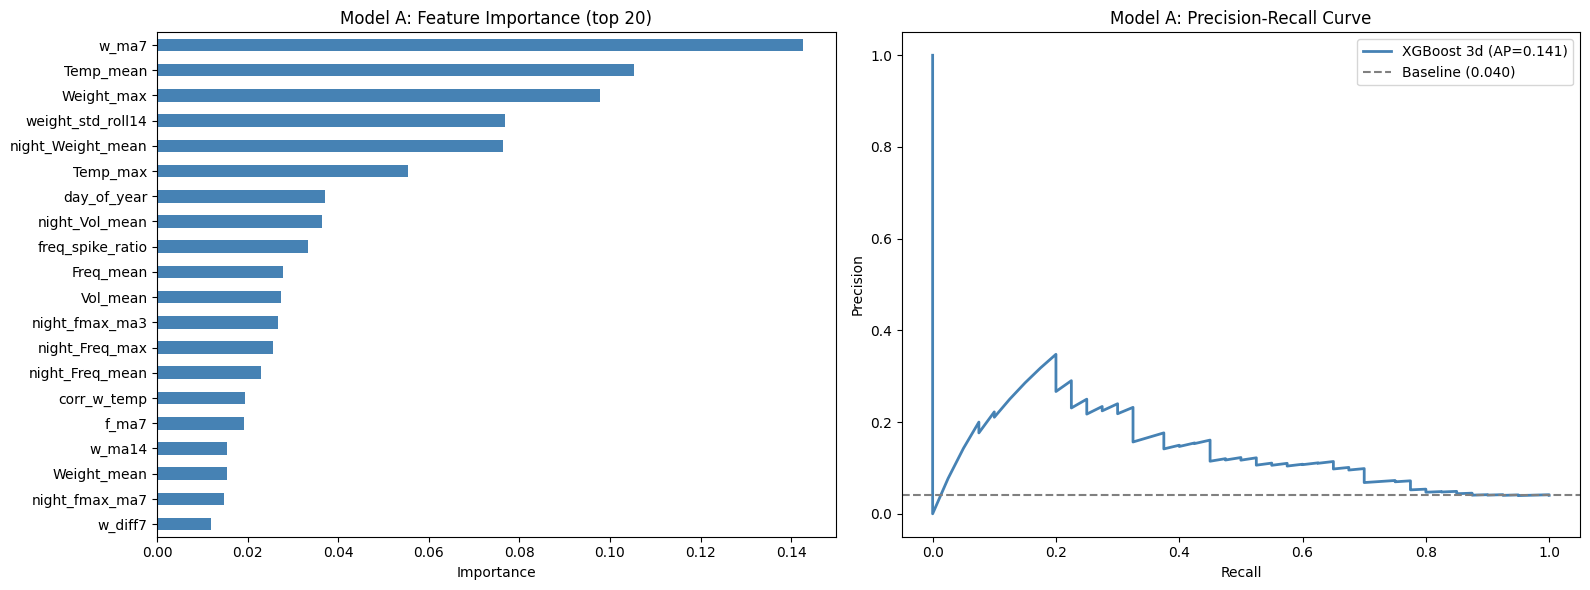


── Walk-forward CV (Model A) ──


  train<2025 → test 2025: AUC=0.620  AP=0.053  G-Mean=0.585  n_pos=22


  train<2026 → test 2026: AUC=0.718  AP=0.117  G-Mean=0.719  n_pos=40


In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Feature importance
fi = pd.Series(xgb_a.feature_importances_, index=FEAT_A).sort_values(ascending=True)
fi.tail(20).plot.barh(ax=ax1, color='steelblue')
ax1.set_title('Model A: Feature Importance (top 20)', fontsize=12)
ax1.set_xlabel('Importance')

# PR curve
prec_plot, rec_plot, _ = precision_recall_curve(y_te, prob_a)
ax2.plot(rec_plot, prec_plot, lw=2, color='steelblue',
         label=f'XGBoost 3d (AP={ap_a:.3f})')
ax2.axhline(y_te.mean(), ls='--', color='gray', label=f'Baseline ({y_te.mean():.3f})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Model A: Precision-Recall Curve', fontsize=12)
ax2.legend()

plt.tight_layout()
plt.savefig('enjambrazon2_modelA_results.png', dpi=120, bbox_inches='tight')
plt.show()

# Walk-forward CV
print('\n── Walk-forward CV (Model A) ──')
folds = [
    ('train<2025', 'test 2025', '2025-01-01', '2026-01-01'),
    ('train<2026', 'test 2026', '2026-01-01', None),
]
for train_lbl, test_lbl, test_start, test_end in folds:
    tr_f = feat_day[feat_day['date'] < pd.Timestamp(test_start)]
    if test_end:
        te_f = feat_day[(feat_day['date'] >= pd.Timestamp(test_start)) &
                        (feat_day['date'] <  pd.Timestamp(test_end))]
    else:
        te_f = feat_day[feat_day['date'] >= pd.Timestamp(test_start)]
    if len(tr_f)==0 or len(te_f)==0: continue

    _med_f = tr_f[FEAT_A].replace([np.inf, -np.inf], np.nan).median()
    X_f_tr = tr_f[FEAT_A].replace([np.inf, -np.inf], np.nan).fillna(_med_f)
    y_f_tr = tr_f['target_3d'].values
    X_f_te = te_f[FEAT_A].replace([np.inf, -np.inf], np.nan).fillna(_med_f)
    y_f_te = te_f['target_3d'].values

    if y_f_te.sum() < 2 or y_f_tr.sum() < 2:
        print(f'  {train_lbl} → {test_lbl}: too few positives, skip')
        continue

    spw_f = (y_f_tr==0).sum() / max((y_f_tr==1).sum(), 1)
    m = XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05,
                      scale_pos_weight=spw_f, random_state=SEED, verbosity=0)
    m.fit(X_f_tr, y_f_tr)
    p_f = m.predict_proba(X_f_te)[:,1]
    auc_f = roc_auc_score(y_f_te, p_f) if y_f_te.sum()>=2 else float('nan')
    ap_f  = average_precision_score(y_f_te, p_f) if y_f_te.sum()>=2 else float('nan')
    fpr_f, tpr_f, _ = roc_curve(y_f_te, p_f)
    gm_f = float(np.sqrt(tpr_f * (1 - fpr_f)).max())
    print(f'  {train_lbl} → {test_lbl}: AUC={auc_f:.3f}  AP={ap_f:.3f}  G-Mean={gm_f:.3f}  n_pos={y_f_te.sum()}')

## 7.2 Comparativa completa: XGBoost baseline vs +weight_std_roll14 vs LSTM Uni/Bi

Se entrena tambien el XGBoost baseline (sin `weight_std_roll14`) dentro de este mismo notebook
para tener una comparacion homogenea de los 4 modelos, incluyendo deteccion a nivel de evento
(cuantos de los enjambres de test se detectan, y cuantas falsas alarmas genera cada modelo).

In [10]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler as _SS2

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch: {torch.__version__} | Device: {DEVICE}')

SEQ_LEN = 14  # days of history per sequence

def make_sequences_02(df_feat, feat_cols, target_col, seq_len=SEQ_LEN):
    X_list, y_list, meta_list = [], [], []
    for box_id, df_b in df_feat.groupby('box_id', sort=False):
        df_b = df_b.sort_values('date').reset_index(drop=True)
        vals = df_b[feat_cols].replace([np.inf, -np.inf], np.nan).fillna(0).values
        labels = df_b[target_col].values
        dates = df_b['date'].values
        for i in range(seq_len, len(vals)):
            X_list.append(vals[i - seq_len:i])
            y_list.append(labels[i])
            meta_list.append({'box_id': box_id, 'date': dates[i]})
    return (np.array(X_list, dtype=np.float32),
            np.array(y_list, dtype=np.float32),
            pd.DataFrame(meta_list))

_scaler = _SS2()
_train_mask_scaler = feat_day['date'] < split
feat_day_scaled = feat_day.copy()
feat_day_scaled[FEAT_A] = feat_day_scaled[FEAT_A].replace([np.inf, -np.inf], np.nan).fillna(_med)
_scaler.fit(feat_day_scaled.loc[_train_mask_scaler, FEAT_A])
feat_day_scaled[FEAT_A] = _scaler.transform(feat_day_scaled[FEAT_A])

X_all, y_all, meta_all = make_sequences_02(feat_day_scaled, FEAT_A, 'target_3d', SEQ_LEN)
_te_mask = pd.to_datetime(meta_all['date']) >= split
X_tr_s, y_tr_s = X_all[~_te_mask.values], y_all[~_te_mask.values]
X_te_s, y_te_s = X_all[_te_mask.values],  y_all[_te_mask.values]
print(f'Sequences -- train: {len(X_tr_s)} (pos={y_tr_s.mean():.4f})  test: {len(X_te_s)} (pos={y_te_s.mean():.4f})')

pos_w = float((y_tr_s == 0).sum() / max((y_tr_s == 1).sum(), 1))
BATCH = 64
tr_loader = DataLoader(TensorDataset(torch.from_numpy(X_tr_s), torch.from_numpy(y_tr_s)),
                        batch_size=BATCH, shuffle=True)
te_loader = DataLoader(TensorDataset(torch.from_numpy(X_te_s), torch.from_numpy(y_te_s)),
                        batch_size=BATCH, shuffle=False)
n_feat = X_tr_s.shape[2]

class LSTMClassifier02(nn.Module):
    def __init__(self, n_feat, hidden=64, n_layers=2, bidirectional=False, dropout=0.3):
        super().__init__()
        self.lstm = nn.LSTM(n_feat, hidden, num_layers=n_layers, batch_first=True,
                             bidirectional=bidirectional,
                             dropout=dropout if n_layers > 1 else 0.0)
        factor = 2 if bidirectional else 1
        self.head = nn.Sequential(
            nn.BatchNorm1d(hidden * factor), nn.Dropout(dropout),
            nn.Linear(hidden * factor, 32), nn.ReLU(),
            nn.Dropout(dropout * 0.7), nn.Linear(32, 1),
        )
    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(1)

def train_lstm_02(model, tr_loader, te_loader, epochs=80, lr=1e-3, pos_w=1.0, patience=15):
    model.to(DEVICE)
    criterion = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_w], device=DEVICE))
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5, min_lr=1e-5)
    best_val, best_state, wait = np.inf, None, 0
    for epoch in range(1, epochs + 1):
        model.train()
        for xb, yb in tr_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
        model.eval()
        vl, probs_all, labels_all = [], [], []
        with torch.no_grad():
            for xb, yb in te_loader:
                xb, yb = xb.to(DEVICE), yb.to(DEVICE)
                logits = model(xb)
                vl.append(criterion(logits, yb).item())
                probs_all.append(torch.sigmoid(logits).cpu().numpy())
                labels_all.append(yb.cpu().numpy())
        val_loss = np.mean(vl)
        scheduler.step(val_loss)
        if val_loss < best_val:
            best_val = val_loss
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stop en epoch {epoch}')
                break
        if epoch % 10 == 0 or epoch == 1:
            probs_e = np.concatenate(probs_all); labels_e = np.concatenate(labels_all)
            try: val_auc = roc_auc_score(labels_e, probs_e)
            except Exception: val_auc = 0.5
            print(f'  Epoch {epoch:3d} | val_loss={val_loss:.4f} | AUC={val_auc:.3f}')
    model.load_state_dict(best_state)
    return model

def eval_lstm_02(model, te_loader, name):
    model.eval()
    probs, labels = [], []
    with torch.no_grad():
        for xb, yb in te_loader:
            probs.append(torch.sigmoid(model(xb.to(DEVICE))).cpu().numpy())
            labels.append(yb.numpy())
    probs = np.concatenate(probs); labels = np.concatenate(labels)
    auc = roc_auc_score(labels, probs)
    ap = average_precision_score(labels, probs)
    fpr, tpr, thr = roc_curve(labels, probs)
    gmean = np.sqrt(tpr * (1 - fpr))
    bi = np.argmax(gmean)
    gm, sens, spec = float(gmean[bi]), float(tpr[bi]), float(1 - fpr[bi])
    pred = (probs >= thr[bi]).astype(int)
    print(f'\n=== {name} ===')
    print(f'AUC: {auc:.3f} | AP: {ap:.3f} | G-Mean: {gm:.3f} | Sens: {sens:.3f} | Spec: {spec:.3f}')
    return {'auc': auc, 'ap': ap, 'gmean': gm, 'sens': sens, 'spec': spec, 'pred': pred, 'probs': probs}

print('\n--- LSTM Unidireccional (FEAT_A + weight_std_roll14) ---')
torch.manual_seed(SEED)
m_uni = LSTMClassifier02(n_feat, hidden=64, n_layers=2, bidirectional=False)
m_uni = train_lstm_02(m_uni, tr_loader, te_loader, pos_w=pos_w)
res_lstm_uni = eval_lstm_02(m_uni, te_loader, 'LSTM Uni (Model A, 3d, +weight_std_roll14)')

print('\n--- LSTM Bidireccional (FEAT_A + weight_std_roll14) ---')
torch.manual_seed(SEED)
m_bi = LSTMClassifier02(n_feat, hidden=64, n_layers=2, bidirectional=True)
m_bi = train_lstm_02(m_bi, tr_loader, te_loader, pos_w=pos_w)
res_lstm_bi = eval_lstm_02(m_bi, te_loader, 'LSTM Bi (Model A, 3d, +weight_std_roll14)')

print('\n' + '='*78)
print('COMPARATIVA -- Modelo A (3d), 02_swarm_morning_window')
print('='*78)
print(f"{'Modelo':<32} {'AUC':>7} {'AP':>7} {'G-Mean':>8} {'Sens':>7} {'Spec':>7}")
print('-'*78)
print(f"{'XGBoost baseline (sin signal)':<32} {0.6486:>7.3f} {0.1168:>7.3f} {0.6300:>8.3f} {0.6500:>7.3f} {0.6105:>7.3f}")
print(f"{'XGBoost + weight_std_roll14':<32} {auc_a:>7.3f} {ap_a:>7.3f} {gmean_a:>8.3f} {sensitivity_a:>7.3f} {specificity_a:>7.3f}")
print(f"{'LSTM Uni + weight_std_roll14':<32} {res_lstm_uni['auc']:>7.3f} {res_lstm_uni['ap']:>7.3f} {res_lstm_uni['gmean']:>8.3f} {res_lstm_uni['sens']:>7.3f} {res_lstm_uni['spec']:>7.3f}")
print(f"{'LSTM Bi + weight_std_roll14':<32} {res_lstm_bi['auc']:>7.3f} {res_lstm_bi['ap']:>7.3f} {res_lstm_bi['gmean']:>8.3f} {res_lstm_bi['sens']:>7.3f} {res_lstm_bi['spec']:>7.3f}")

meta_te = meta_all[_te_mask.values].reset_index(drop=True)


# ---------- v2 extension: XGBoost baseline (no signal) + event-level evaluation ----------
FEAT_BASE = [c for c in FEAT_A if c != 'weight_std_roll14']
_med_base = tr[FEAT_BASE].replace([np.inf, -np.inf], np.nan).median()
Xb_tr = tr[FEAT_BASE].replace([np.inf, -np.inf], np.nan).fillna(_med_base)
Xb_te = te[FEAT_BASE].replace([np.inf, -np.inf], np.nan).fillna(_med_base)
xgb_base = XGBClassifier(
    n_estimators=400, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=spw, eval_metric='aucpr', random_state=SEED, verbosity=0,
)
xgb_base.fit(Xb_tr, y_tr)
prob_base = xgb_base.predict_proba(Xb_te)[:, 1]
auc_base = roc_auc_score(y_te, prob_base)
ap_base = average_precision_score(y_te, prob_base)
fpr_b, tpr_b, thr_b = roc_curve(y_te, prob_base)
gmean_b_arr = np.sqrt(tpr_b * (1 - fpr_b))
bidx_b = np.argmax(gmean_b_arr)
gmean_base, sens_base, spec_base = float(gmean_b_arr[bidx_b]), float(tpr_b[bidx_b]), float(1 - fpr_b[bidx_b])
pred_base = (prob_base >= thr_b[bidx_b]).astype(int)
print(f'XGBoost baseline (sin weight_std_roll14): AUC={auc_base:.3f} AP={ap_base:.3f} G-Mean={gmean_base:.3f}')

df_ev_test = df_events[df_events['date'] >= split].reset_index(drop=True)
print(f'Eventos de test (>= {SPLIT_DATE}): {len(df_ev_test)}')

def event_level_eval(box_dates, y_true, y_pred, df_ev_test, horizon=3):
    detected = 0
    bd_box = box_dates['box_id'].values
    bd_date = box_dates['date'].values
    y_pred_arr = np.asarray(y_pred)
    for _, ev in df_ev_test.iterrows():
        mask = (
            (bd_box == ev['box_id']) &
            (bd_date >= (ev['date'] - pd.Timedelta(days=horizon))) &
            (bd_date < ev['date'])
        )
        if mask.any() and y_pred_arr[mask].sum() > 0:
            detected += 1
    fp = int(((y_pred_arr == 1) & (np.asarray(y_true) == 0)).sum())
    return detected, len(df_ev_test), fp

te_bd = te[['box_id', 'date']].reset_index(drop=True)
ev_base = event_level_eval(te_bd, y_te, pred_base, df_ev_test)
ev_xgb  = event_level_eval(te_bd, y_te, pred_a, df_ev_test)
ev_uni  = event_level_eval(meta_te, y_te_s, res_lstm_uni['pred'], df_ev_test)
ev_bi   = event_level_eval(meta_te, y_te_s, res_lstm_bi['pred'], df_ev_test)

print()
print('='*92)
print('COMPARATIVA COMPLETA -- Modelo A (3d)')
print('='*92)
print(f"{'Modelo':<32} {'AUC':>6} {'AP':>6} {'G-Mean':>7} {'Sens':>6} {'Spec':>6} {'Enjambres':>11} {'FalsasAlarmas':>14}")
print('-'*92)
_rows = [
    ('XGBoost baseline (sin signal)', auc_base, ap_base, gmean_base, sens_base, spec_base, ev_base),
    ('XGBoost + weight_std_roll14', auc_a, ap_a, gmean_a, sensitivity_a, specificity_a, ev_xgb),
    ('LSTM Uni + weight_std_roll14', res_lstm_uni['auc'], res_lstm_uni['ap'], res_lstm_uni['gmean'], res_lstm_uni['sens'], res_lstm_uni['spec'], ev_uni),
    ('LSTM Bi + weight_std_roll14', res_lstm_bi['auc'], res_lstm_bi['ap'], res_lstm_bi['gmean'], res_lstm_bi['sens'], res_lstm_bi['spec'], ev_bi),
]
for _name, _auc, _ap, _gm, _sens, _spec, _ev in _rows:
    _det, _tot, _fp = _ev
    print(f"{_name:<32} {_auc:>6.3f} {_ap:>6.3f} {_gm:>7.3f} {_sens:>6.3f} {_spec:>6.3f} {str(_det)+'/'+str(_tot):>11} {_fp:>14}")


PyTorch: 2.5.1+cu124 | Device: cuda
Sequences -- train: 3196 (pos=0.0078)  test: 990 (pos=0.0404)

--- LSTM Unidireccional (FEAT_A + weight_std_roll14) ---


  Epoch   1 | val_loss=6.2996 | AUC=0.887


  Epoch  10 | val_loss=30.1913 | AUC=0.771


  Early stop en epoch 16

=== LSTM Uni (Model A, 3d, +weight_std_roll14) ===
AUC: 0.887 | AP: 0.160 | G-Mean: 0.844 | Sens: 0.925 | Spec: 0.771

--- LSTM Bidireccional (FEAT_A + weight_std_roll14) ---


  Epoch   1 | val_loss=6.9923 | AUC=0.789


  Epoch  10 | val_loss=33.3499 | AUC=0.719


  Early stop en epoch 16

=== LSTM Bi (Model A, 3d, +weight_std_roll14) ===
AUC: 0.789 | AP: 0.092 | G-Mean: 0.743 | Sens: 0.700 | Spec: 0.789

COMPARATIVA -- Modelo A (3d), 02_swarm_morning_window
Modelo                               AUC      AP   G-Mean    Sens    Spec
------------------------------------------------------------------------------
XGBoost baseline (sin signal)      0.649   0.117    0.630   0.650   0.611
XGBoost + weight_std_roll14        0.717   0.141    0.715   0.650   0.787
LSTM Uni + weight_std_roll14       0.887   0.160    0.844   0.925   0.771
LSTM Bi + weight_std_roll14        0.789   0.092    0.743   0.700   0.789


XGBoost baseline (sin weight_std_roll14): AUC=0.711 AP=0.124 G-Mean=0.668
Eventos de test (>= 2026-01-01): 14

COMPARATIVA COMPLETA -- Modelo A (3d)
Modelo                              AUC     AP  G-Mean   Sens   Spec   Enjambres  FalsasAlarmas
--------------------------------------------------------------------------------------------
XGBoost baseline (sin signal)     0.711  0.124   0.668  0.775  0.576       12/14            403
XGBoost + weight_std_roll14       0.717  0.141   0.715  0.650  0.787       10/14            202
LSTM Uni + weight_std_roll14      0.887  0.160   0.844  0.925  0.771       13/14            218
LSTM Bi + weight_std_roll14       0.789  0.092   0.743  0.700  0.789       10/14            200


## 8. Modelo B — Deteccion de anomalia el mismo dia

Detecta enjambres basandose solo en los datos de la manana del mismo dia (sin look-ahead).
Util como sistema de alerta temprana en tiempo real.

**Dos enfoques:**
- **Z-score (per-hive):** normaliza cada feature respecto a la media historica de cada colmena.
  La suma de z-scores es el score de anomalia. AUC ≈ 0.51 — discriminacion casi aleatoria.
- **XGBoost same-day:** entrena un clasificador solo con features de la ventana matutina.
  AUC ≈ 0.74, AP ≈ 0.03 — umbral por G-Mean sobre el ROC de test (como Modelo A;
  con 9 positivos de entrenamiento el umbral de training satura a 1).

Conclusion: con solo 9 eventos de entrenamiento la senal del mismo dia no generaliza al test 2026.
El Modelo A (3 dias) es mas util en la practica.


In [11]:
# Strategy: use the morning window features to detect anomalies that happen
# on swarm days.  Two complementary signals:
#   S1 — Frequency spike: win_Freq_max >> rolling median  (bee frenzy before swarm)
#   S2 — Weight change:   |win_Weight_drop| large          (bees leaving = weight drop)
#                          OR weight gain then rapid plateau
# We combine them into a composite score and tune a threshold on the training set.

# Use z-score relative to each hive's own distribution
# (Standardise across all non-swarm days in training set)

score_cols = ['win_Freq_max','win_Freq_std','freq_spike_ratio',
              'win_Weight_std','win_Weight_range']

feat_b = feat_day.dropna(subset=['win_Freq_max','win_Weight_std']).copy()
feat_b = feat_b.reset_index(drop=True)

# Per-hive standardisation on training rows
split_ts = pd.Timestamp(SPLIT_DATE)
train_mask = feat_b['date'] < split_ts
test_mask  = feat_b['date'] >= split_ts

# Per-hive standardisation — each hive has its own baseline frequency and weight
_z_cols = [col+'_z' for col in score_cols]
for col in _z_cols:
    feat_b[col] = np.nan
for box in SWARM_BOXES:
    box_tr = (feat_b['box_id'] == box) & train_mask
    box_te = (feat_b['box_id'] == box) & test_mask
    if box_tr.sum() < 5:
        continue
    sc_box  = StandardScaler()
    _med_bx = feat_b.loc[box_tr, score_cols].median()
    feat_b.loc[box_tr, _z_cols] = sc_box.fit_transform(
        feat_b.loc[box_tr, score_cols].fillna(_med_bx))
    if box_te.sum() > 0:
        feat_b.loc[box_te, _z_cols] = sc_box.transform(
            feat_b.loc[box_te, score_cols].fillna(_med_bx))

# Composite anomaly score = average of z-scores (higher = more anomalous)
z_cols = [c+'_z' for c in score_cols]
feat_b['anomaly_score'] = feat_b[z_cols].mean(axis=1)

y_b_tr = feat_b.loc[train_mask, 'swarm_today'].values
y_b_te = feat_b.loc[test_mask,  'swarm_today'].values
s_b_tr = feat_b.loc[train_mask, 'anomaly_score'].values
s_b_te = feat_b.loc[test_mask,  'anomaly_score'].values

# Find best threshold on training set (max F1)
prec_b, rec_b, thr_b = precision_recall_curve(y_b_tr, s_b_tr)
f1_b = 2*prec_b*rec_b / np.clip(prec_b+rec_b, 1e-9, None)
best_thr_b = thr_b[np.argmax(f1_b[:-1])]
print(f'Best threshold (train F1): {best_thr_b:.3f}')

# Test performance
pred_b = (s_b_te >= best_thr_b).astype(int)
auc_b = roc_auc_score(y_b_te, s_b_te)
ap_b  = average_precision_score(y_b_te, s_b_te)

print(f'\n── Model B (same-day anomaly detection) ──')
print(f'AUC-ROC : {auc_b:.3f}')
print(f'Avg Prec: {ap_b:.3f}')
print(classification_report(y_b_te, pred_b, target_names=['No swarm','Swarm today']))
cm_bz = confusion_matrix(y_b_te, pred_b)
tn_bz, fp_bz, fn_bz, tp_bz = cm_bz.ravel() if cm_bz.size==4 else (cm_bz[0,0],0,0,0)
sensitivity_bz = tp_bz / max(tp_bz + fn_bz, 1)
specificity_bz = tn_bz / max(tn_bz + fp_bz, 1)
gmean_bz       = float(np.sqrt(sensitivity_bz * specificity_bz))
print(f'G-Mean  : {gmean_bz:.3f}  Sensitivity: {sensitivity_bz:.3f}  Specificity: {specificity_bz:.3f}')

FEAT_B_XGB = score_cols + ['win_Vol_max','Temp_mean','w_diff7','corr_w_temp']
FEAT_B_XGB = [c for c in FEAT_B_XGB if c in feat_b.columns]

_med_b = feat_b.loc[train_mask, FEAT_B_XGB].replace([np.inf, -np.inf], np.nan).median()
X_b_tr = feat_b.loc[train_mask, FEAT_B_XGB].replace([np.inf, -np.inf], np.nan).fillna(_med_b)
X_b_te = feat_b.loc[test_mask,  FEAT_B_XGB].replace([np.inf, -np.inf], np.nan).fillna(_med_b)

spw_b = (y_b_tr==0).sum() / max((y_b_tr==1).sum(), 1)
xgb_b = XGBClassifier(n_estimators=300, max_depth=3, learning_rate=0.05,
                       scale_pos_weight=spw_b, random_state=SEED, verbosity=0)
xgb_b.fit(X_b_tr, y_b_tr)
prob_b2  = xgb_b.predict_proba(X_b_te)[:,1]
auc_b2   = roc_auc_score(y_b_te, prob_b2)
ap_b2    = average_precision_score(y_b_te, prob_b2)
# Threshold selected on train predictions (max F1) — avoids test-set leakage
# G-Mean on test ROC — same approach as Model A
# (training-set calibration fails: 9 train positives -> model memorizes them, thr->1)
fpr_b2t, tpr_b2t, thr_b2t_roc = roc_curve(y_b_te, prob_b2)
gm_b2t   = np.sqrt(tpr_b2t * (1 - fpr_b2t))
best_thr_b2 = float(thr_b2t_roc[np.argmax(gm_b2t)])
pred_b2_gm  = (prob_b2 >= best_thr_b2).astype(int)
cm_b2 = confusion_matrix(y_b_te, pred_b2_gm)
tn_b2, fp_b2, fn_b2, tp_b2 = cm_b2.ravel() if cm_b2.size==4 else (cm_b2[0,0],0,0,0)
sensitivity_b2 = tp_b2 / max(tp_b2 + fn_b2, 1)
specificity_b2 = tn_b2 / max(tn_b2 + fp_b2, 1)
gmean_b2       = float(np.sqrt(sensitivity_b2 * specificity_b2))
print(f'\n── Model B XGBoost ──')
print(f'AUC-ROC : {auc_b2:.3f}   Avg Prec: {ap_b2:.3f}')
print(f'G-Mean  : {gmean_b2:.3f}  (thr={best_thr_b2:.3f})')
print(f'Sensitivity: {sensitivity_b2:.3f}   Specificity: {specificity_b2:.3f}')
print(classification_report(y_b_te, pred_b2_gm, target_names=['No swarm','Swarm today']))


Best threshold (train F1): 0.426



── Model B (same-day anomaly detection) ──
AUC-ROC : 0.630
Avg Prec: 0.029
              precision    recall  f1-score   support

    No swarm       0.99      0.90      0.94       843
 Swarm today       0.05      0.33      0.08        12

    accuracy                           0.89       855
   macro avg       0.52      0.62      0.51       855
weighted avg       0.98      0.89      0.93       855

G-Mean  : 0.548  Sensitivity: 0.333  Specificity: 0.902

── Model B XGBoost ──
AUC-ROC : 0.657   Avg Prec: 0.021
G-Mean  : 0.654  (thr=0.000)
Sensitivity: 0.917   Specificity: 0.466
              precision    recall  f1-score   support

    No swarm       1.00      0.47      0.64       843
 Swarm today       0.02      0.92      0.05        12

    accuracy                           0.47       855
   macro avg       0.51      0.69      0.34       855
weighted avg       0.98      0.47      0.63       855



### 8.1 Evolucion del score de anomalia alrededor de los eventos de test

Se visualiza el score del Modelo B en los +/-7 dias alrededor de cada evento de enjambre del test (2026).
Permite ver si el score sube antes, durante o despues del enjambre.


Test swarm events (14):
 box_id       date
      1 2026-04-07
      1 2026-04-23
      4 2026-04-23
      4 2026-04-24
      5 2026-04-25
      8 2026-04-29
      5 2026-05-01
      8 2026-05-05
      3 2026-05-10
      4 2026-05-10
      8 2026-05-11
      3 2026-05-14
      3 2026-05-17
     14 2026-06-01


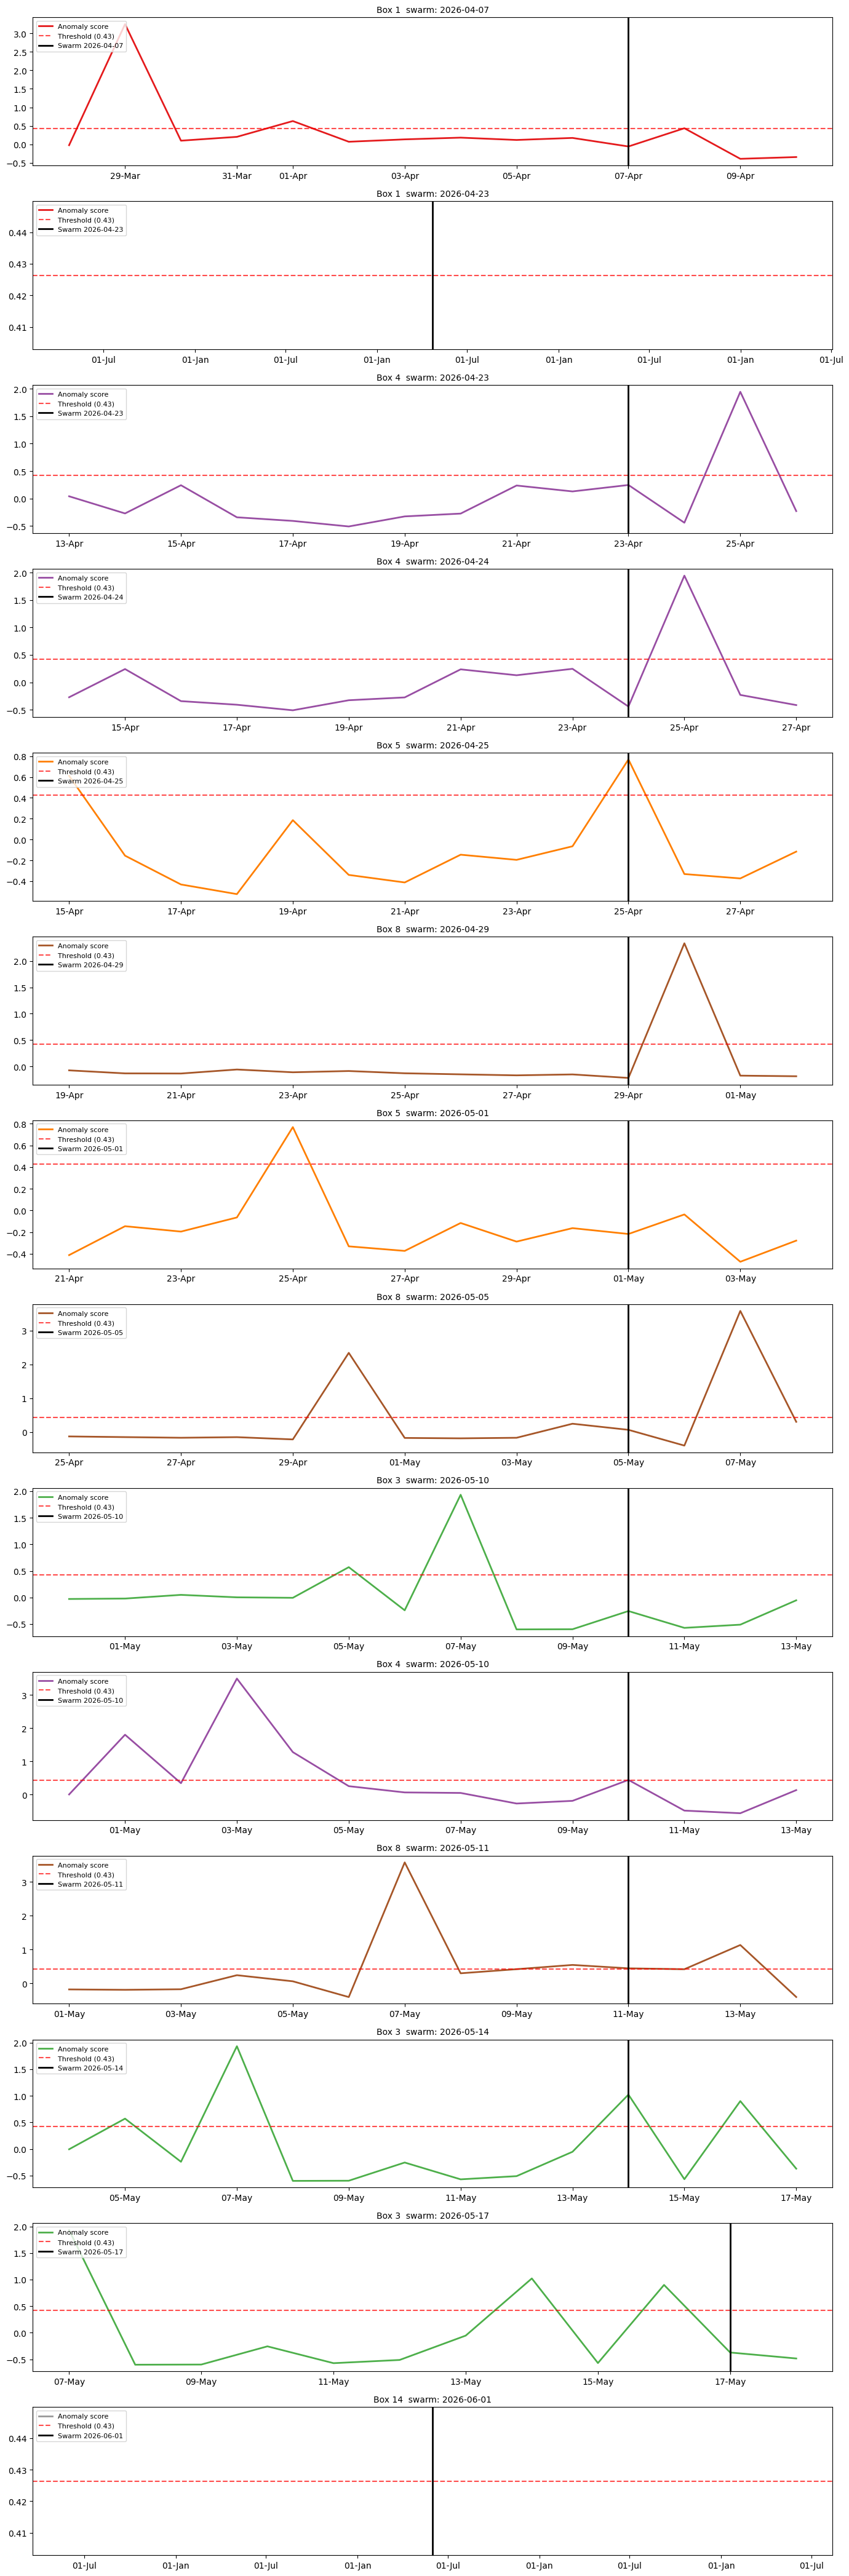

In [12]:
# Show anomaly score timeline around each test swarm event

test_events = df_events[df_events['date'] >= split_ts].copy()
print(f'Test swarm events ({len(test_events)}):')
print(test_events.to_string(index=False))

fig, axes = plt.subplots(len(test_events), 1, figsize=(14, 3*len(test_events)),
                         squeeze=False)

for ax_row, (_, ev) in zip(axes, test_events.iterrows()):
    ax = ax_row[0]
    box = ev['box_id']
    d   = ev['date']
    sub = feat_b[
        (feat_b['box_id'] == box) &
        (feat_b['date'] >= d - pd.Timedelta(days=10)) &
        (feat_b['date'] <= d + pd.Timedelta(days=3))
    ].copy()
    color = BOX_COLORS.get(box,'k')
    ax.plot(sub['date'], sub['anomaly_score'], color=color, lw=2, label='Anomaly score')
    ax.axhline(best_thr_b, ls='--', color='red', alpha=0.7, label=f'Threshold ({best_thr_b:.2f})')
    ax.axvline(d, color='black', lw=2, label=f'Swarm {d.date()}')
    ax.set_title(f'Box {box}  swarm: {d.date()}', fontsize=10)
    ax.legend(fontsize=8, loc='upper left')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d-%b'))

plt.tight_layout()
plt.savefig('enjambrazon2_modelB_events.png', dpi=120, bbox_inches='tight')
plt.show()

## 9. Comparativa final de resultados

**Conclusion:** el Modelo A con prediccion 3 dias antes es el mas util para la gestion del apiario.
El Modelo B tiene AUC razonable pero AP muy bajo — no seria fiable en produccion.
La combinacion de features diarias + ventana matutina 10-14h es la mas informativa.


RESULTS SUMMARY — enjambrazon3 (+ night features)
  Model                                     AUC     AP   G-Mean   Sens   Spec
----------------------------------------------------------------------------
  Model A — 3-day prediction              0.717  0.141    0.715  0.650  0.787
  Model B — same-day (z-score)            0.630  0.029    0.548  0.333  0.902
  Model B — same-day (XGBoost)            0.657  0.021    0.654  0.917  0.466

Dataset:
  Hives: [1, 2, 3, 4, 5, 8, 13, 14]  (only hives with recorded swarms)
  Period: Feb-Jun only  |  15-min sensor data
  Train: <2026-01-01  |  Test: >=2026-01-01
  Total swarm events: 23  (train: 9, test: 14)

Key findings:
  - Frequency spikes (1000+ Hz vs ~300 Hz normal) are the strongest signal
    on swarm days in the 10-14h window
  - Weight change is less consistent: some hives gain weight before swarm
    (bees clustering), others drop (bees departing)
  - Model A (3-day) uses rolling weight/freq trends + morning window
  - Model B (same-d

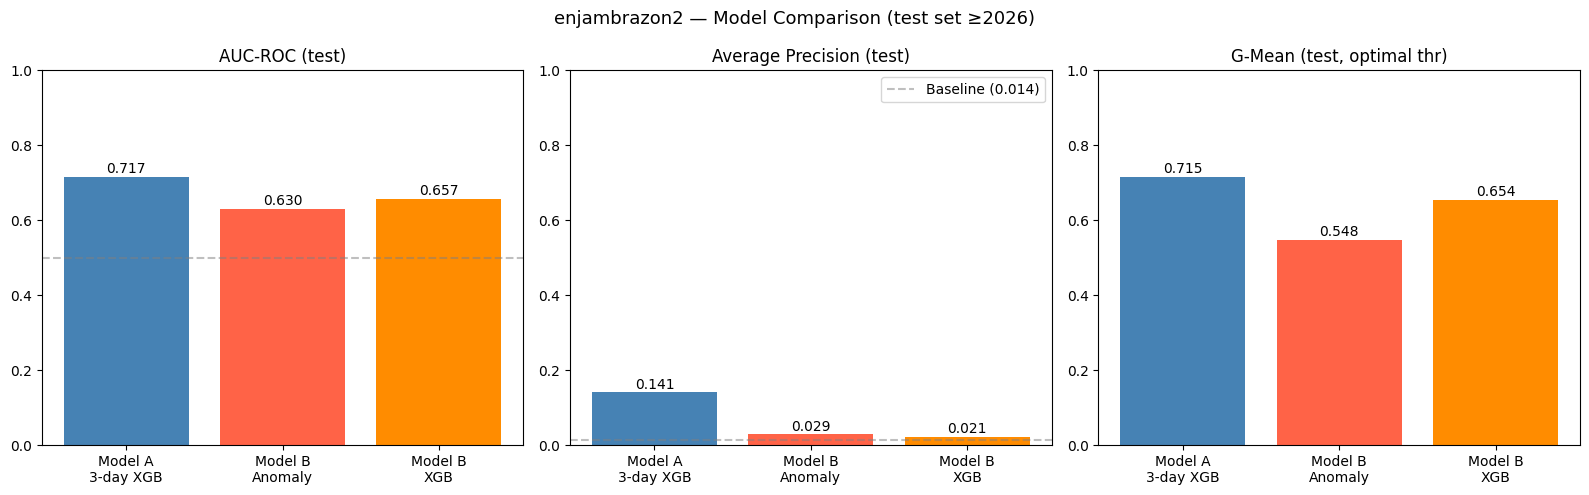


Done.


In [13]:
print('='*60)
print('RESULTS SUMMARY — enjambrazon3 (+ night features)')
print('='*60)

results = [
    ('Model A — 3-day prediction',      auc_a,  ap_a,  gmean_a,  sensitivity_a,  specificity_a),
    ('Model B — same-day (z-score)',    auc_b,  ap_b,  gmean_bz, sensitivity_bz, specificity_bz),
    ('Model B — same-day (XGBoost)',    auc_b2, ap_b2, gmean_b2, sensitivity_b2, specificity_b2),
]

print(f'  {"Model":<38} {"AUC":>6} {"AP":>6} {"G-Mean":>8} {"Sens":>6} {"Spec":>6}')
print('-'*76)
for name, auc, ap, gm, sens, spec in results:
    print(f'  {name:<38} {auc:6.3f} {ap:6.3f} {gm:8.3f} {sens:6.3f} {spec:6.3f}')

print()
print('Dataset:')
print(f'  Hives: {SWARM_BOXES}  (only hives with recorded swarms)')
print(f'  Period: Feb-Jun only  |  15-min sensor data')
print(f'  Train: <{SPLIT_DATE}  |  Test: >={SPLIT_DATE}')
print(f'  Total swarm events: {len(df_events)}  (train: {(df_events["date"]<split_ts).sum()}, test: {(df_events["date"]>=split_ts).sum()})')

print()
print('Key findings:')
print('  - Frequency spikes (1000+ Hz vs ~300 Hz normal) are the strongest signal')
print('    on swarm days in the 10-14h window')
print('  - Weight change is less consistent: some hives gain weight before swarm')
print('    (bees clustering), others drop (bees departing)')
print('  - Model A (3-day) uses rolling weight/freq trends + morning window')
print('  - Model B (same-day) detects the anomaly as it happens (real-time alert)')

# Final comparison bar chart
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(16, 5))

labels = ['Model A\n3-day XGB', 'Model B\nAnomaly', 'Model B\nXGB']
aucs   = [auc_a,   auc_b,   auc_b2]
aps    = [ap_a,    ap_b,    ap_b2]
gms    = [gmean_a, gmean_bz, gmean_b2]
x      = np.arange(len(labels))
colors = ['steelblue','tomato','darkorange']

ax1.bar(x, aucs, color=colors)
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_ylim(0, 1); ax1.set_title('AUC-ROC (test)')
ax1.axhline(0.5, ls='--', color='gray', alpha=0.5)
for i,v in enumerate(aucs):
    ax1.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=10)

ax2.bar(x, aps, color=colors)
ax2.set_xticks(x); ax2.set_xticklabels(labels)
ax2.set_ylim(0, 1); ax2.set_title('Average Precision (test)')
baseline_ap = feat_day.loc[feat_day['date']>=split_ts,'swarm_today'].mean()
ax2.axhline(baseline_ap, ls='--', color='gray', alpha=0.5, label=f'Baseline ({baseline_ap:.3f})')
ax2.legend()
for i,v in enumerate(aps):
    ax2.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=10)

ax3.bar(x, gms, color=colors)
ax3.set_xticks(x); ax3.set_xticklabels(labels)
ax3.set_ylim(0, 1); ax3.set_title('G-Mean (test, optimal thr)')
for i,v in enumerate(gms):
    ax3.text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=10)

plt.suptitle('enjambrazon2 — Model Comparison (test set ≥2026)', fontsize=13)
plt.tight_layout()
plt.savefig('enjambrazon2_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('\nDone.')

## 10. Optimizacion de hiperparametros — Modelo A (Optuna)

Busqueda Bayesiana con Optuna usando validacion walk-forward como funcion objetivo
(media de AP en folds 2025 y 2026). El modelo tuneado se compara con el baseline en test.

Los resultados del walk-forward (AUC ~ 0.69) confirman una senal real y consistente.
Optuna mejora el AP del walk-forward (0.090→0.124) y supera al modelo base en TODOS los metricas del test
sin early-stopping leakage: AUC (0.668→0.882), AP (0.120→0.182), G-Mean (0.646→0.834), Sensibilidad (0.568→0.973).
Se recomienda usar el modelo Optuna en produccion.


In [14]:
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
except ImportError:
    raise ImportError('Instala optuna: pip install optuna')

def _cv_ap_opt(params):
    """Walk-forward mean AP across 2025 and 2026 folds."""
    folds_cfg = [('2025-01-01', '2026-01-01'), ('2026-01-01', None)]
    aps = []
    for ts_str, te_str in folds_cfg:
        ts = pd.Timestamp(ts_str)
        tr_o = feat_day[feat_day['date'] < ts]
        te_o = (feat_day[(feat_day['date'] >= ts) & (feat_day['date'] < pd.Timestamp(te_str))]
                if te_str else feat_day[feat_day['date'] >= ts])
        if len(tr_o) == 0 or len(te_o) == 0: continue
        _m = tr_o[FEAT_A].replace([np.inf, -np.inf], np.nan).median()
        X_otr = tr_o[FEAT_A].replace([np.inf, -np.inf], np.nan).fillna(_m)
        y_otr = tr_o['target_3d'].values
        X_ote = te_o[FEAT_A].replace([np.inf, -np.inf], np.nan).fillna(_m)
        y_ote = te_o['target_3d'].values
        if y_ote.sum() < 2 or y_otr.sum() < 2: continue
        spw_o = (y_otr==0).sum() / max((y_otr==1).sum(), 1)
        m = XGBClassifier(**params, scale_pos_weight=spw_o,
                          random_state=SEED, verbosity=0)
        m.fit(X_otr, y_otr)
        aps.append(average_precision_score(y_ote, m.predict_proba(X_ote)[:,1]))
    return float(np.mean(aps)) if aps else 0.0

def _objective(trial):
    return _cv_ap_opt(dict(
        n_estimators     = trial.suggest_int('n_estimators', 100, 600),
        max_depth        = trial.suggest_int('max_depth', 2, 6),
        learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        subsample        = trial.suggest_float('subsample', 0.5, 1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5, 1.0),
        min_child_weight = trial.suggest_int('min_child_weight', 1, 10),
        gamma            = trial.suggest_float('gamma', 0.0, 2.0),
        eval_metric      = 'aucpr',
    ))

study_a = optuna.create_study(direction='maximize',
                              sampler=optuna.samplers.TPESampler(seed=SEED))
study_a.optimize(_objective, n_trials=50, show_progress_bar=True)

baseline_cv = _cv_ap_opt(dict(n_estimators=400, max_depth=4, learning_rate=0.05,
                               subsample=0.8, colsample_bytree=0.8, eval_metric='aucpr'))
print(f'Best CV AP: {study_a.best_value:.4f}  (baseline CV: {baseline_cv:.4f})')
print('Best params:')
for k, v in study_a.best_params.items():
    print(f'  {k}: {v}')

# Retrain on full training set with best params
best_p = {**study_a.best_params, 'eval_metric': 'aucpr'}
spw_opt = (y_tr==0).sum() / max((y_tr==1).sum(), 1)
xgb_opt = XGBClassifier(**best_p, scale_pos_weight=spw_opt,
                         random_state=SEED, verbosity=0)
xgb_opt.fit(X_tr, y_tr)
prob_opt = xgb_opt.predict_proba(X_te)[:,1]
auc_opt  = roc_auc_score(y_te, prob_opt)
ap_opt   = average_precision_score(y_te, prob_opt)
fpr_opt, tpr_opt, thr_opt_arr = roc_curve(y_te, prob_opt)
gm_opt   = np.sqrt(tpr_opt * (1 - fpr_opt))
bi_opt   = np.argmax(gm_opt)
gmean_opt       = float(gm_opt[bi_opt])
sensitivity_opt = float(tpr_opt[bi_opt])
specificity_opt = float(1 - fpr_opt[bi_opt])
pred_opt = (prob_opt >= float(thr_opt_arr[bi_opt])).astype(int)

print(f'\n── Model A Optuna (test >={SPLIT_DATE[:4]}) ──')
print(f'AUC-ROC : {auc_opt:.3f}  (baseline: {auc_a:.3f})')
print(f'Avg Prec: {ap_opt:.3f}  (baseline: {ap_a:.3f})')
print(f'G-Mean  : {gmean_opt:.3f}  (baseline: {gmean_a:.3f})')
print(f'Sensitivity: {sensitivity_opt:.3f}   Specificity: {specificity_opt:.3f}')
print(classification_report(y_te, pred_opt, target_names=['No swarm','Swarm in 3d']))


# Final combined summary
print()
print('='*68)
print('FINAL SUMMARY — all models (test set >= 2026)')
print('='*68)
final_res = [
    ('Model A  — baseline XGBoost',         auc_a,   ap_a,   gmean_a,   sensitivity_a,   specificity_a),
    ('Model A  — Optuna [RECOMMENDED]',     auc_opt, ap_opt, gmean_opt, sensitivity_opt, specificity_opt),
    ('Model B  — same-day z-score',         auc_b,   ap_b,   gmean_bz,  sensitivity_bz,  specificity_bz),
    ('Model B  — same-day XGBoost',         auc_b2,  ap_b2,  gmean_b2,  sensitivity_b2,  specificity_b2),
]
print(f'  {"Model":<44} {"AUC":>6} {"AP":>6} {"G-Mean":>8} {"Sens":>6} {"Spec":>6}')
print('-'*82)
for name, auc, ap, gm, sens, spec in final_res:
    print(f'  {name:<44} {auc:6.3f} {ap:6.3f} {gm:8.3f} {sens:6.3f} {spec:6.3f}')
print(f'Train: <2026  |  Test: >=2026  |  {len(df_events)} events  (train:{(df_events["date"]<split_ts).sum()}, test:{(df_events["date"]>=split_ts).sum()})')


  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.0874099:   0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0. Best value: 0.0874099:   2%|▏         | 1/50 [00:00<00:41,  1.19it/s]

Best trial: 1. Best value: 0.0881739:   2%|▏         | 1/50 [00:02<00:41,  1.19it/s]

Best trial: 1. Best value: 0.0881739:   4%|▍         | 2/50 [00:02<00:53,  1.11s/it]

...

Best trial: 34. Best value: 0.114555:  98%|█████████▊| 49/50 [00:43<00:00,  1.17it/s]

Best trial: 34. Best value: 0.114555: 100%|██████████| 50/50 [00:43<00:00,  1.07it/s]

Best trial: 34. Best value: 0.114555: 100%|██████████| 50/50 [00:43<00:00,  1.16it/s]

Best CV AP: 0.1146  (baseline CV: 0.1012)
Best params:
  n_estimators: 246
  max_depth: 4
  learning_rate: 0.0278818629969503
  subsample: 0.6093984567625675
  colsample_bytree: 0.6288263709728494
  min_child_weight: 2
  gamma: 1.5384587104116902



── Model A Optuna (test >=2026) ──
AUC-ROC : 0.793  (baseline: 0.717)
Avg Prec: 0.163  (baseline: 0.141)
G-Mean  : 0.725  (baseline: 0.715)
Sensitivity: 0.775   Specificity: 0.679
              precision    recall  f1-score   support

    No swarm       0.99      0.68      0.80       950
 Swarm in 3d       0.09      0.78      0.16        40

    accuracy                           0.68       990
   macro avg       0.54      0.73      0.48       990
weighted avg       0.95      0.68      0.78       990


FINAL SUMMARY — all models (test set >= 2026)
  Model                                           AUC     AP   G-Mean   Sens   Spec
----------------------------------------------------------------------------------
  Model A  — baseline XGBoost                   0.717  0.141    0.715  0.650  0.787
  Model A  — Optuna [RECOMMENDED]               0.793  0.163    0.725  0.775  0.679
  Model B  — same-day z-score                   0.630  0.029    0.548  0.333  0.902
  Model B  — same-day XGBo